<a href="https://colab.research.google.com/github/Mathildeholst/Speciale/blob/main/OpenData_real_voices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import data

Setting up API

In [ ]:
!pip install requests pandas --quiet

import requests
import pandas as pd
import json

API_KEY = "*****"
BASE_URL = "https://donerdinstemme.dk/jsonapi"

headers = {
    "api-key": API_KEY,
    "Accept": "application/json",
}

Get all donations

In [ ]:
def hent_alle_donationer(page_size=50):
    alle = []
    page = 0

    while True:
        print(f"Henter side {page + 1}...", end=" ")
        url = f"{BASE_URL}/dds"
        params = {
            "page[limit]": page_size,
            "page[offset]": page * page_size
        }
        response = requests.get(url, headers=headers, params=params)

        if response.status_code != 200:
            print(f"Fejl {response.status_code}")
            break

        data = response.json()
        donationer = data.get("data", [])

        if not donationer:
            print("Ingen flere data.")
            break

        alle.extend(donationer)
        print(f"({len(donationer)} hentet)")

        if len(donationer) < page_size:
            break

        page += 1

    print(f"\nSamlet: {len(alle)} donationer")
    return alle

alle = hent_alle_donationer()

Convert to DataFrame and add sentence_id

In [ ]:
rækker = []
for d in alle:
    meta = d.get("metadata", {})

    file_info = d.get("file", {})
    uri_info = file_info.get("uri", {}) if file_info else {}

    row = {
        "id":           d.get("id"),
        "tekst":        meta.get("text"),
        "user":         meta.get("user"),
        "fødselsår":    meta.get("birth_year"),
        "dialekt":      meta.get("dialect"),
        "køn":          meta.get("gender"),
        "postnummer":   meta.get("postal_code"),
        "varighed_sek": meta.get("durationInSeconds"),
        "word_error_rate": d.get("whisper_guess_word_error_rate")
    }

    rækker.append(row)

df = pd.DataFrame(rækker)

sætning_mapping = {tekst: i for i, tekst in enumerate(df['tekst'].unique())}
df['sætning_id'] = df['tekst'].map(sætning_mapping)

print(f"Antal donationer: {len(df)}")
print(f"Unikke brugere: {df['user'].nunique()}")
print(f"Unikke sætninger: {df['sætning_id'].nunique()}")
print(f"Gns. varighed: {df['varighed_sek'].astype(float).mean():.1f} sek")

df.head()

Antal donationer: 8088
Unikke brugere: 498
Unikke sætninger: 649
Gns. varighed: 12.0 sek


,id,tekst,user,fødselsår,dialekt,køn,postnummer,varighed_sek,word_error_rate,file_url,sætning_id
0,456d1b04-f429-4606-972e-3a8e536b5a8c,Søren cykler hver dag fra sin lejlighed til si...,5a32a6b5c5062c7cfe41032c85e7f623f0e36e6a,1950_erne,oestjysk,male,6000,54,0.870968,None,0
1,38488add-5d78-4e66-bc9d-8dcfdb0079ea,I dag starter Søren sin tur ved at tage cyklen...,5a32a6b5c5062c7cfe41032c85e7f623f0e36e6a,1950_erne,oestjysk,male,6000,14,0.321429,None,1
2,659147ab-f913-4107-9819-6b03d987ed80,Kommunen har gjort meget for at forbedre cykel...,5a32a6b5c5062c7cfe41032c85e7f623f0e36e6a,1950_erne,oestjysk,male,6000,7,0.173913,None,2
3,4f595695-1b54-4706-b9fc-9e17d07eb1da,Undervejs passerer Søren flere lyskryds med sæ...,5a32a6b5c5062c7cfe41032c85e7f623f0e36e6a,1950_erne,oestjysk,male,6000,9,0.250000,None,3
4,b86384e2-0970-4ba3-bb74-f375e95c7cab,Søren ser også nye skilte for cyklister. Skilt...,5a32a6b5c5062c7cfe41032c85e7f623f0e36e6a,1950_erne,oestjysk,male,6000,8,0.214286,None,4


Get audio files

In [ ]:
import requests

def download_audio(donation_id, filename="audio.wav"):
    url = f"https://donerdinstemme.dk/jsonapi/dds/{donation_id}/file"

    r = requests.get(url, headers=headers)
    fil_data = r.json()

    fil_url = fil_data["data"]["uri"]["absolute_url"]

    r_lyd = requests.get(fil_url, headers=headers)

    if r_lyd.status_code == 200:
        with open(filename, "wb") as f:
            f.write(r_lyd.content)
        print(f"Gemt som {filename}")
    else:
        print("Kunne ikke hente fil")

#Data cleaning and generate CSV file

Check duration and NAs

In [ ]:
import pandas as pd

bins = [-10, 0, 5, 10, 15, 20, 30, 60]
labels = ['-10 til 0', '0 til 5', '5 til 10', '10 til 15', '15 til 20', '20 til 30', '30 til 60']

df['varighed_sek'] = pd.to_numeric(df['varighed_sek'], errors='coerce')

df['varighed_interval'] = pd.cut(df['varighed_sek'], bins=bins, labels=labels)

varighed_tabel = df['varighed_interval'].value_counts().sort_index().to_frame('antal')
varighed_tabel['procent'] = (varighed_tabel['antal'] / len(df) * 100).round(1)
print("Fordeling af varighed:")
print(varighed_tabel.to_string())

print("\nManglende værdier per kolonne:")
na_tabel = pd.DataFrame({
    'antal_na': df.isnull().sum(),
    'procent_na': (df.isnull().sum() / len(df) * 100).round(1)
})
print(na_tabel.to_string())
print("Ingen manglende værdier" if na_tabel['antal_na'].sum() == 0 else "")

Fordeling af varighed:
                   antal  procent
varighed_interval                
-10 til 0              4      0.0
0 til 5              118      1.5
5 til 10            2611     32.3
10 til 15           4332     53.6
15 til 20            771      9.5
20 til 30            228      2.8
30 til 60             24      0.3

Manglende værdier per kolonne:
                   antal_na  procent_na
id                        0         0.0
tekst                     0         0.0
user                      0         0.0
fødselsår                 0         0.0
dialekt                   0         0.0
køn                       0         0.0
postnummer             1281        15.8
varighed_sek              0         0.0
word_error_rate          17         0.2
file_url               8088       100.0
sætning_id                0         0.0
varighed_interval         0         0.0



Remove all data that is under 2 seconds

In [ ]:
print("Optagelser under 2 sekunder:")
print(df[df['varighed_sek'] < 2][['id', 'user', 'varighed_sek', 'tekst']].to_string())
print(f"\nAntal: {(df['varighed_sek'] < 2).sum()}")

Optagelser under 2 sekunder:
                                        id                                      user  varighed_sek                                                                                                                                                                                                                                                              tekst
789   ab6c3944-87f4-4b59-a208-27a629907c1b  abe9c77ba679aa83c75f2e12120e2b31850c0c36             0                                                                                                 Efter højtlæsningen hjælper Sara en gruppe studerende, som har brug for materiale til et projekt. Hun viser dem, hvordan de kan finde relevante bøger og artikler.
1899  c99068fe-2dbb-479a-9688-b9a941c1d804  f18d347a52b15a25d773d272b5b50807301483ba             1                                                                                       Hver dag starter Mette sin runde i en af byens parker. Hun tjekker, om

In [ ]:
før = len(df)
df = df[df['varighed_sek'] >= 2]
efter = len(df)

print(f"Før rensning: {før} optagelser")
print(f"Efter rensning: {efter} optagelser")
print(f"Fjernet: {før - efter} optagelser")

Før rensning: 8088 optagelser
Efter rensning: 8080 optagelser
Fjernet: 8 optagelser


In [ ]:
print(len(df))

8080


Remove missing word error rate

In [ ]:
print("Optagelser med manglende WER:")
print(df[df['word_error_rate'].isna()][['id', 'user', 'word_error_rate', 'tekst']].to_string())
print(f"\nAntal: {df['word_error_rate'].isna().sum()}")

Optagelser med manglende WER:
                                        id                                      user  word_error_rate                                                                                                                                                                                     tekst
4178  bab96fbb-8fd6-4c95-8b85-e0b111dbdea2  09683d2fdb9e182d1ea8bff008efa2921d581999              NaN  Senere på dagen deltager Kasper i en workshop om samskabelse. Her møder han både borgere og repræsentanter fra forskellige organisationer, der ønsker at samarbejde om lokale projekter.
4737  a5103af5-c963-4cb0-a19d-05a00fe17e8e  8060a39378bb8f5c4dc70c91040431058acc3be9              NaN                    Hen på eftermiddagen besøger Thomas en skole, hvor han holder et oplæg om affaldssortering for eleverne. Han forklarer, hvordan de kan hjælpe med at passe på miljøet.
8074  918af54a-0baf-4a5f-ac48-848f41d0f59c  e93c53c660e2f3de14d8e247cc1ce527b86cbfe5              NaN     

In [ ]:
før = len(df)
df = df.dropna(subset=['word_error_rate'])
efter = len(df)

print(f"Før rensning: {før} optagelser")
print(f"Efter rensning: {efter} optagelser")
print(f"Fjernet: {før - efter} optagelser")

Før rensning: 8080 optagelser
Efter rensning: 8064 optagelser
Fjernet: 16 optagelser


Remove invalid values in word error rate

In [ ]:
før = len(df)
df = df[(df['word_error_rate'] >= 0) & (df['word_error_rate'] <= 1)]
efter = len(df)

print(f"Før rensning: {før}")
print(f"Efter rensning: {efter}")
print(f"Fjernet: {før - efter}")

Før rensning: 8064
Efter rensning: 8053
Fjernet: 11


Check the distribution of word error rate

In [ ]:
import pandas as pd

bins = [0, 0.1, 0.2, 0.3, 0.5, 1]
labels = ['0 til 0.1', '0.1 til 0.2', '0.2 til 0.3', '0.3 til 0.5', '0.5 til 1']

df['wer_interval'] = pd.cut(df['word_error_rate'], bins=bins, labels=labels, include_lowest=True)

wer_tabel = df['wer_interval'].value_counts().sort_index().to_frame('antal')
wer_tabel['procent'] = (wer_tabel['antal'] / len(df) * 100).round(1)

print("Fordeling af Word Error Rate:")
print(wer_tabel.to_string())

Fordeling af Word Error Rate:
              antal  procent
wer_interval                
0 til 0.1      3952     49.1
0.1 til 0.2    1790     22.2
0.2 til 0.3     881     10.9
0.3 til 0.5     970     12.0
0.5 til 1       460      5.7


Inspect two audio files with word error rate above 50%

In [ ]:
df_bad = df[df['word_error_rate'] > 0.5]
df_bad[['id', 'word_error_rate']].head(2)

,id,word_error_rate
0,456d1b04-f429-4606-972e-3a8e536b5a8c,0.870968
6,8458455f-f533-4d85-a05c-d3ec7176905c,0.538462


In [ ]:
download_audio(df_bad.iloc[0]['id'], "dårlig1.wav")
download_audio(df_bad.iloc[1]['id'], "dårlig2.wav")

Gemt som dårlig1.wav
Gemt som dårlig2.wav


In [ ]:
from IPython.display import Audio, display

display(Audio("dårlig1.wav"))
display(Audio("dårlig2.wav"))

Inspect two audio files with word error rate below 20%

In [ ]:
df_good = df[df['word_error_rate'] < 0.2]
df_good[['id', 'word_error_rate']].head(2)

,id,word_error_rate
2,659147ab-f913-4107-9819-6b03d987ed80,0.173913
7,1427f72b-d7ae-4547-9ad6-af873111b0b4,0.064516


In [ ]:
download_audio(df_good.iloc[0]['id'], "god1.wav")
download_audio(df_good.iloc[1]['id'], "god2.wav")

Gemt som god1.wav
Gemt som god2.wav


In [ ]:
from IPython.display import Audio, display

display(Audio("god1.wav"))
display(Audio("god2.wav"))

Remove recordings with word error rate over 50%

In [ ]:
før = len(df)
df = df[df['word_error_rate'] <= 0.5]
efter = len(df)

print(f"Før rensning: {før} optagelser")
print(f"Efter rensning: {efter} optagelser")
print(f"Fjernet: {før - efter} optagelser")

Før rensning: 8053 optagelser
Efter rensning: 7593 optagelser
Fjernet: 460 optagelser


Save and download CSV

In [ ]:
df_export = df[['id', 'tekst', 'user', 'fødselsår', 'dialekt', 'køn', 'postnummer', 'varighed_sek', 'word_error_rate', 'sætning_id']].copy()

df_export['word_error_rate'] = df_export['word_error_rate'].map(lambda x: f"{x:.3f}".replace('.', ','))

df_export.to_csv("clean_data.csv", index=False, sep=';')

from google.colab import files
files.download("clean_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Visual analysis of data

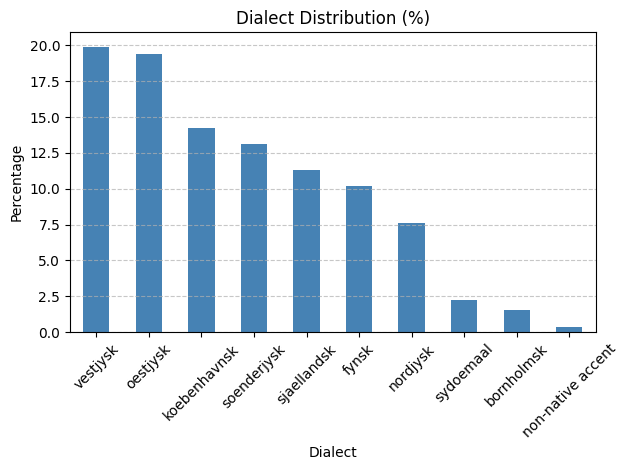

In [ ]:
import matplotlib.pyplot as plt

dialect_pct = df['dialekt'].value_counts(normalize=True) * 100

dialect_pct.plot(kind='bar',color='steelblue')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Dialect Distribution (%)")
plt.xlabel("Dialect")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

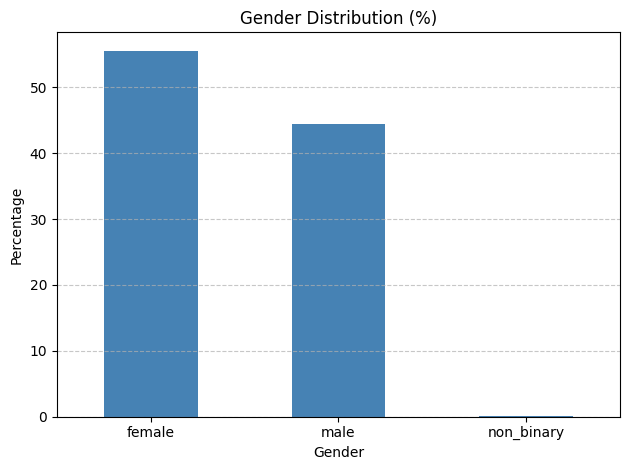

In [ ]:
gender_pct = df['køn'].value_counts(normalize=True) * 100

gender_pct.plot(kind='bar',color='steelblue')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Gender Distribution (%)")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

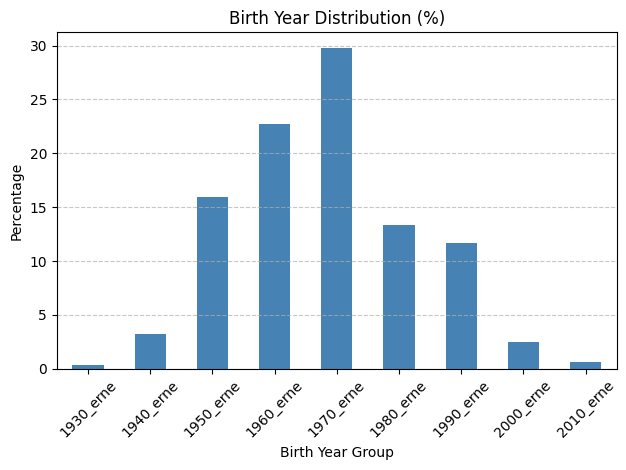

In [ ]:
order = [
    '1930_erne', '1940_erne', '1950_erne', '1960_erne',
    '1970_erne', '1980_erne', '1990_erne', '2000_erne', '2010_erne'
]

birth_pct = df['fødselsår'].value_counts(normalize=True) * 100
birth_pct = birth_pct.reindex(order)

birth_pct.plot(kind='bar', color='steelblue')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Birth Year Distribution (%)")
plt.xlabel("Birth Year Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

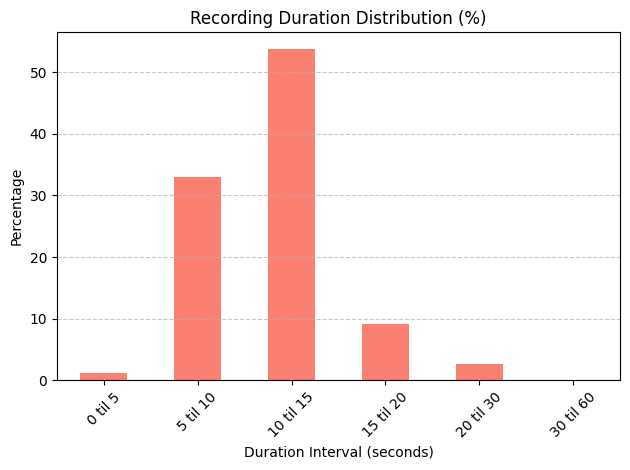

In [ ]:
df['varighed_interval'] = df['varighed_interval'].cat.remove_unused_categories()
duration_pct = df['varighed_interval'].value_counts(normalize=True).sort_index() * 100

duration_pct.plot(kind='bar',color='salmon')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Recording Duration Distribution (%)")
plt.xlabel("Duration Interval (seconds)")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

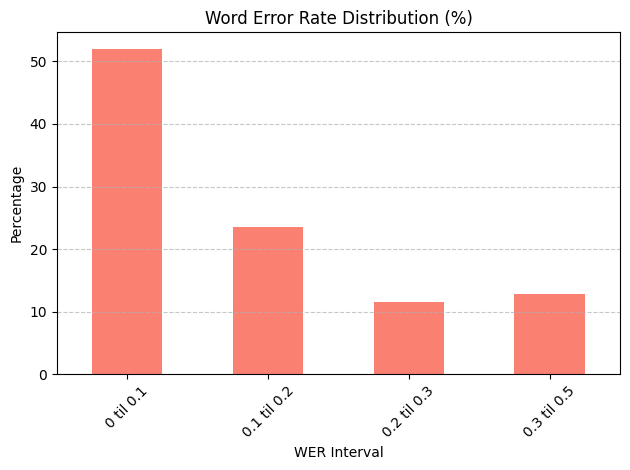

In [ ]:
df['wer_interval'] = df['wer_interval'].cat.remove_unused_categories()
wer_pct = df['wer_interval'].value_counts(normalize=True).sort_index() * 100

wer_pct.plot(kind='bar', color='salmon')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Word Error Rate Distribution (%)")
plt.xlabel("WER Interval")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(f"Total recordings: {len(df)}")
print(f"Unique users: {df['user'].nunique()}")

Total recordings: 7593
Unique users: 489


In [ ]:
bins = [0, 5, 10, 20, 50, 100, 300]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '100+']

user_bins = pd.cut(user_counts, bins=bins, labels=labels)

user_table = user_bins.value_counts().sort_index().to_frame('count')
user_table['percentage'] = (user_table['count'] / len(user_counts) * 100).round(1)

print(user_table)

        count  percentage
count                    
1-5        55        11.2
6-10      122        24.9
11-20     186        38.0
21-50     115        23.5
51-100     10         2.0
100+        1         0.2


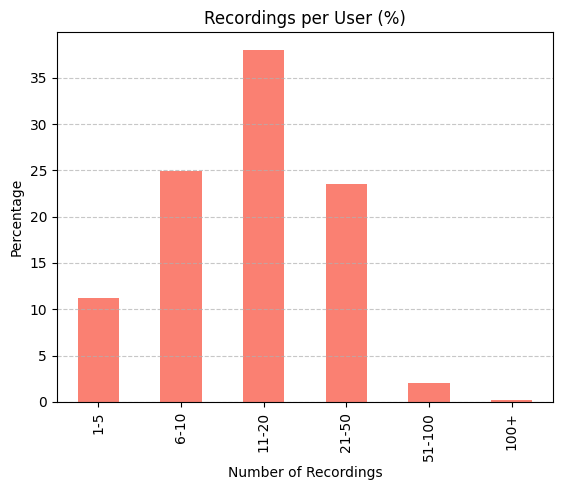

In [ ]:
user_table['percentage'].plot(kind='bar', color='salmon')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Recordings per User (%)")
plt.xlabel("Number of Recordings")
plt.ylabel("Percentage")
plt.show()

In [ ]:
print(f"Total recordings: {len(df)}")
print(f"Unique sentences: {df['sætning_id'].nunique()}")

Total recordings: 7593
Unique sentences: 643


In [ ]:
text_counts = df['sætning_id'].value_counts()

bins = [0, 5, 10, 20, 50, 100]
labels = ['1-5', '6-10', '11-20', '21-50', '50+']

text_bins = pd.cut(text_counts, bins=bins, labels=labels)

text_table = text_bins.value_counts().sort_index().to_frame('count')
text_table['percentage'] = (text_table['count'] / len(text_counts) * 100).round(1)

print(text_table)

       count  percentage
count                   
1-5      369        57.4
6-10     103        16.0
11-20     50         7.8
21-50    111        17.3
50+       10         1.6


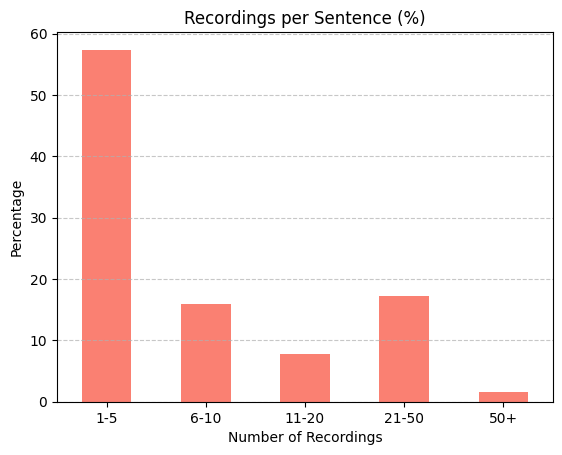

In [ ]:
text_table['percentage'].plot(kind='bar', color='salmon')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title("Recordings per Sentence (%)")
plt.xlabel("Number of Recordings")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

#Split data into train, validation and test

The dataset was split into training, validation, and test sets

In [ ]:
from sklearn.model_selection import train_test_split

train_users, temp_users = train_test_split(
    df['user'].unique(),
    test_size=0.30,
    random_state=42
)

val_users, test_users = train_test_split(
    temp_users,
    test_size=0.50,
    random_state=42
)

train = df[df['user'].isin(train_users)]
val = df[df['user'].isin(val_users)]
test = df[df['user'].isin(test_users)]

In [ ]:
print(f"Antal i træningssæt: {len(train)}")
print(f"Antal i valideringssæt: {len(val)}")
print(f"Antal i testsæt: {len(test)}")

Antal i træningssæt: 5405
Antal i valideringssæt: 1088
Antal i testsæt: 1100


In [ ]:
print(len(train) + len(val) + len(test))

7593


In [ ]:
total_recordings = len(df)

train_pct = (len(train) / total_recordings) * 100
val_pct = (len(val) / total_recordings) * 100
test_pct = (len(test) / total_recordings) * 100

print(f"Træningssæt: {train_pct:.2f}%")
print(f"Valideringssæt: {val_pct:.2f}%")
print(f"Testsæt: {test_pct:.2f}%")

Træningssæt: 71.18%
Valideringssæt: 14.33%
Testsæt: 14.49%


Verify no overlap between speakers

In [ ]:
set(train['user']).intersection(set(val['user']))
set(train['user']).intersection(set(test['user']))
set(val['user']).intersection(set(test['user']))

set()

Generate and download csv file for each split

In [ ]:
train.to_csv("train.csv", index=False, sep=';')
val.to_csv("val.csv", index=False, sep=';')
test.to_csv("test.csv", index=False, sep=';')

In [ ]:
from google.colab import files

files.download("train.csv")
files.download("val.csv")
files.download("test.csv")

#Visual analysis of our train, val and test sets

Upload csv files

In [ ]:
from google.colab import files
files.upload()

In [ ]:
from google.colab import files
files.upload()

In [ ]:
from google.colab import files
files.upload()

In [ ]:
import pandas as pd

train_df = pd.read_csv("train.csv", sep=';')
val_df = pd.read_csv("val.csv", sep=';')
test_df = pd.read_csv("test.csv", sep=';')

Check that the lengths match our split

In [ ]:
print(f"Længde af train_df: {len(train_df)}")
print(f"Længde af val_df: {len(val_df)}")
print(f"Længde af test_df: {len(test_df)}")

Længde af train_df: 5405
Længde af val_df: 1088
Længde af test_df: 1100


In [ ]:
import matplotlib.pyplot as plt

def plot_three(df1, df2, df3, column, titles, colors):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for df, ax, title, color in zip(
        [df1, df2, df3],
        axes,
        titles,
        colors
    ):
        dist = df[column].value_counts(normalize=True) * 100

        dist.plot(kind='bar', ax=ax, color=color)

        ax.set_title(title)
        ax.set_ylabel("Percentage")
        ax.set_xlabel(column)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

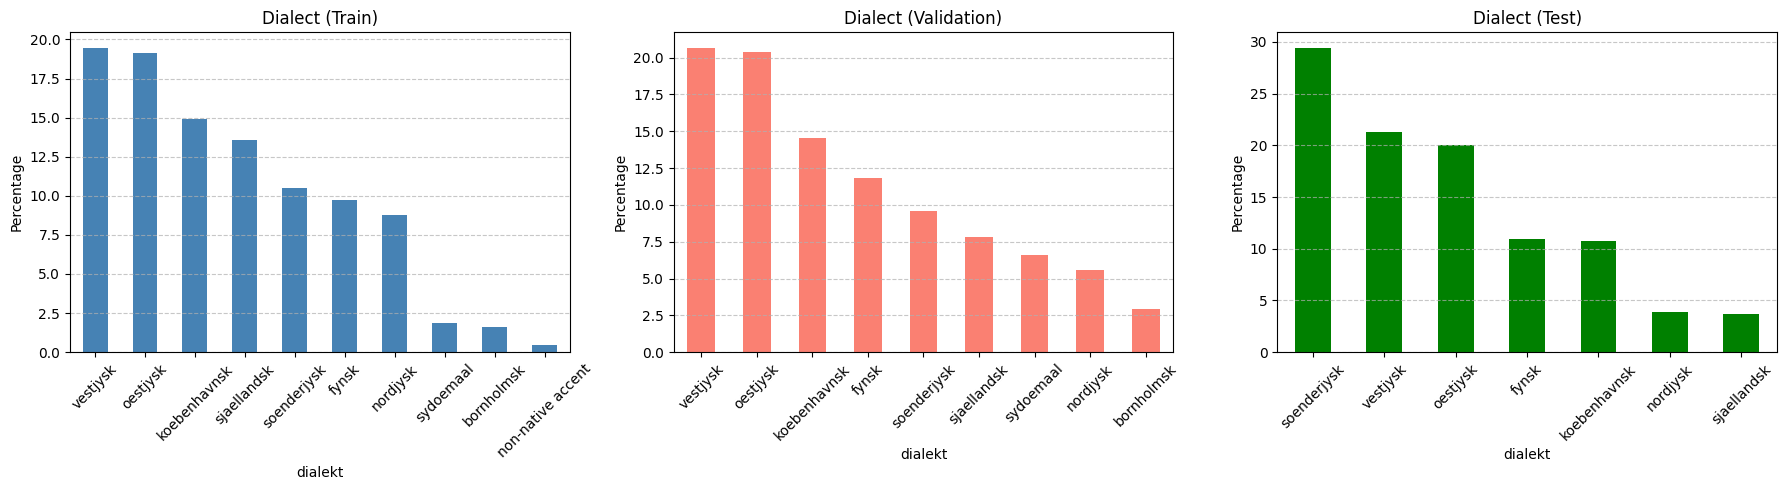

In [ ]:
plot_three(
    train_df,
    val_df,
    test_df,
    column="dialekt",
    titles=[
        "Dialect (Train)",
        "Dialect (Validation)",
        "Dialect (Test)"
    ],
    colors=["steelblue", "salmon", "green"]
)

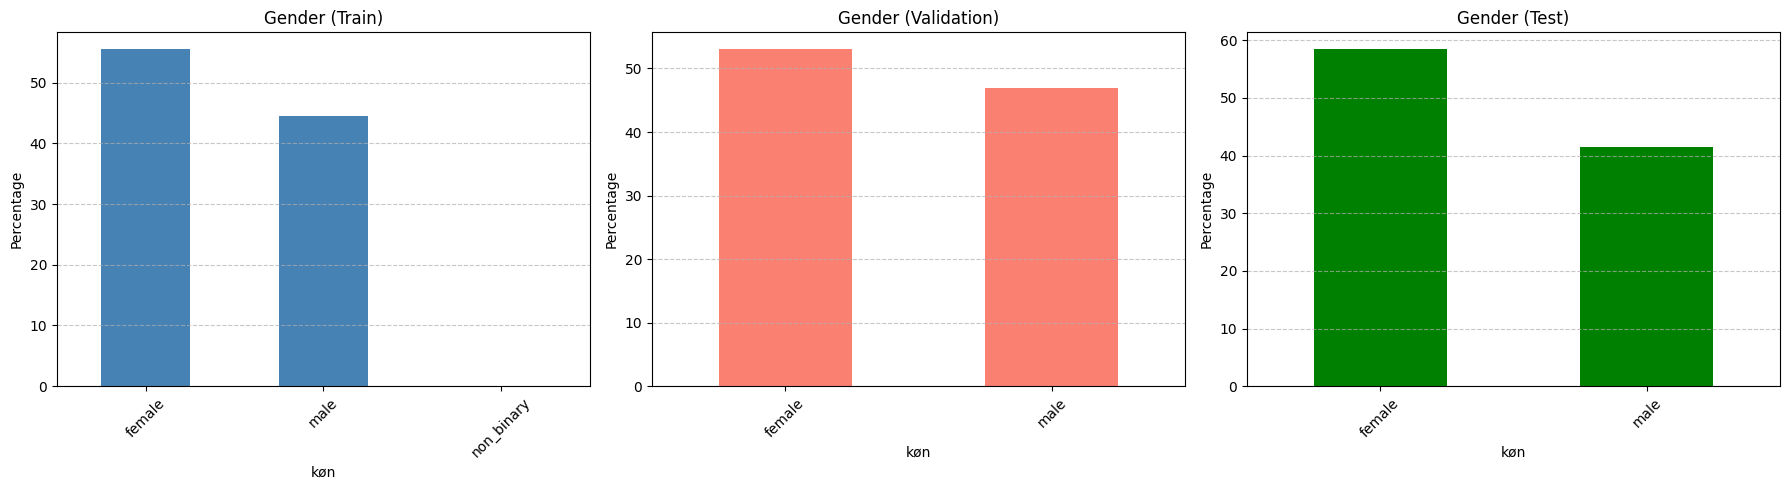

In [ ]:
plot_three(
    train_df,
    val_df,
    test_df,
    column="køn",
    titles=[
        "Gender (Train)",
        "Gender (Validation)",
        "Gender (Test)"
    ],
    colors=["steelblue", "salmon", "green"]
)

In [ ]:
def plot_birth_year_three(df1, df2, df3):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for df, ax, title, color in zip(
        [df1, df2, df3],
        axes,
        ["Train", "Validation", "Test"],
        ["steelblue", "salmon", "green"]
    ):
        dist = df['fødselsår'].value_counts(normalize=True).sort_index() * 100

        dist.plot(kind='bar', ax=ax, color=color)

        ax.set_title(f"Birth Year Distribution ({title})")
        ax.set_ylabel("Percentage")
        ax.set_xlabel("Birth Year Group")
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

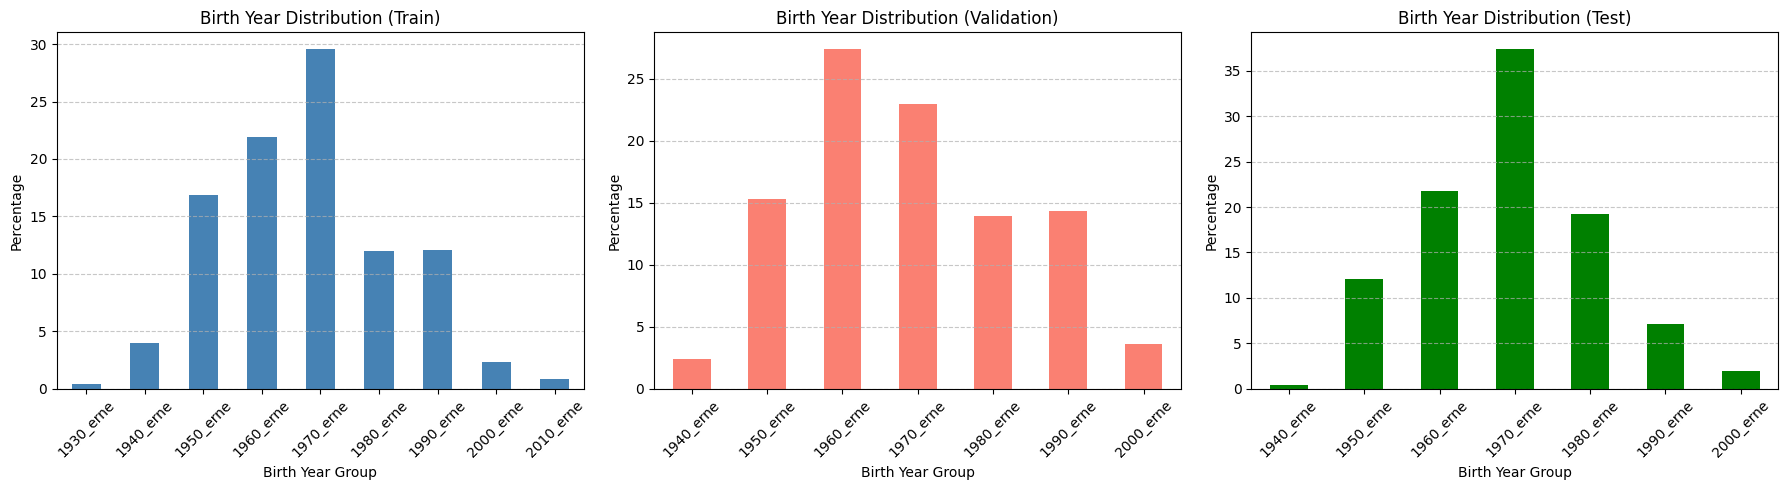

In [ ]:
plot_birth_year_three(train_df, val_df, test_df)

In [ ]:
def plot_duration_three(df1, df2, df3):

    bins = [0, 5, 10, 15, 20, 30, 60]
    labels = ['0-5', '5-10', '10-15', '15-20', '20-30', '30-60']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for df, ax, title, color in zip(
        [df1, df2, df3],
        axes,
        ["Train", "Validation", "Test"],
        ["steelblue", "salmon", "green"]
    ):
        temp_df = df.copy()

        temp_df['duration_bin'] = pd.cut(
            temp_df['varighed_sek'], bins=bins, labels=labels
        )

        dist = temp_df['duration_bin'].value_counts(normalize=True).sort_index() * 100

        dist.plot(kind='bar', ax=ax, color=color)

        ax.set_title(f"Recording Duration ({title})")
        ax.set_ylabel("Percentage")
        ax.set_xlabel("Seconds")
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

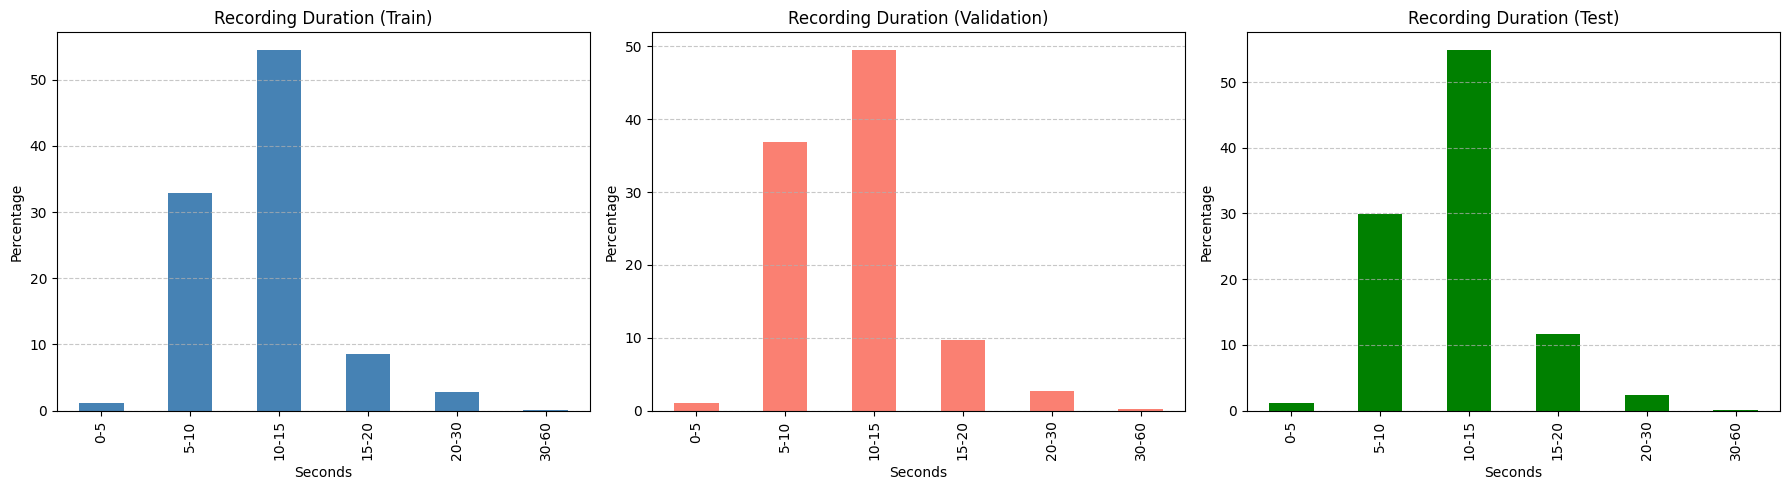

In [ ]:
plot_duration_three(train_df, val_df, test_df)

In [ ]:
def plot_wer_three(df1, df2, df3):

    bins = [0, 0.1, 0.2, 0.3, 0.5, 1]
    labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.5', '0.5-1']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for df, ax, title, color in zip(
        [df1, df2, df3],
        axes,
        ["Train", "Validation", "Test"],
        ["steelblue", "salmon", "green"]
    ):
        temp_df = df.copy()  # 🔥 vigtig

        temp_df['wer_bin'] = pd.cut(
            temp_df['word_error_rate'], bins=bins, labels=labels
        )

        dist = temp_df['wer_bin'].value_counts(normalize=True).sort_index() * 100

        dist.plot(kind='bar', ax=ax, color=color)

        ax.set_title(f"Word Error Rate ({title})")
        ax.set_ylabel("Percentage")
        ax.set_xlabel("WER")
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

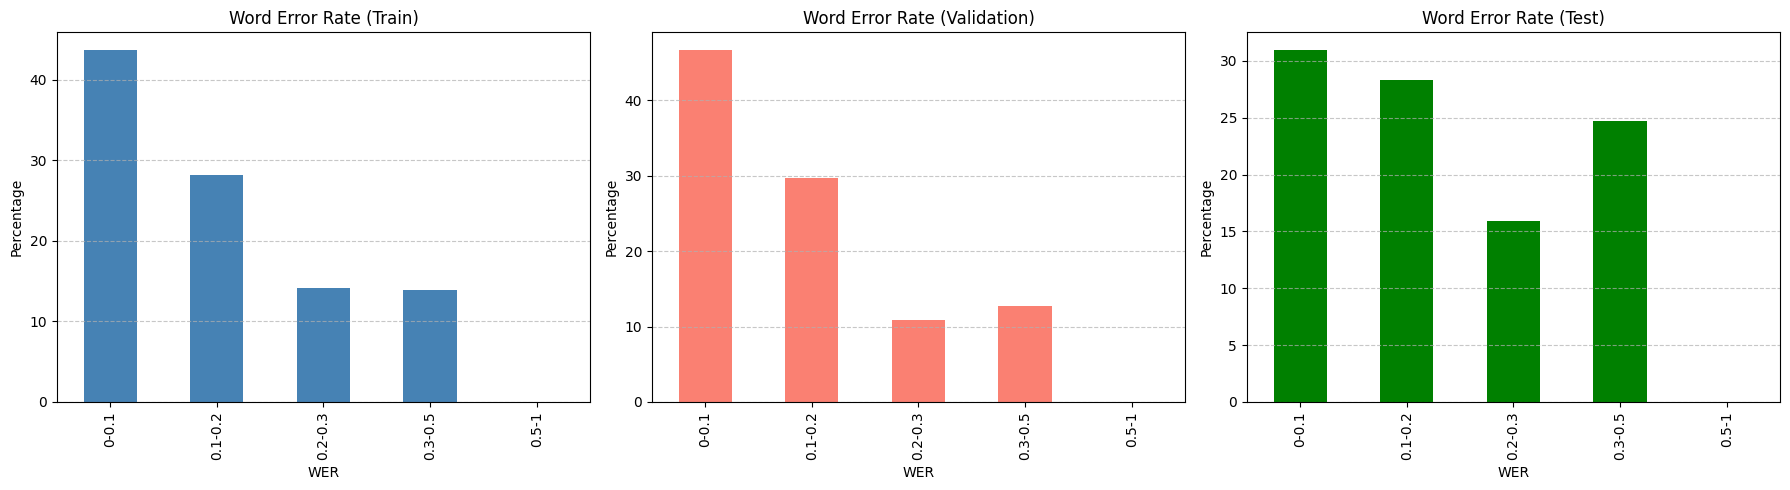

In [ ]:
plot_wer_three(train_df, val_df, test_df)

In [ ]:
def plot_user_distribution(df1, df2, df3):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for df, ax, title, color in zip(
        [df1, df2, df3],
        axes,
        ["Train", "Validation", "Test"],
        ["steelblue", "salmon", "green"]
    ):
        user_counts = df['user'].value_counts()

        bins = [0, 5, 10, 20, 50, 100, 300]
        labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '100+']

        user_bins = pd.cut(user_counts, bins=bins, labels=labels)

        dist = user_bins.value_counts(normalize=True).sort_index() * 100

        dist.plot(kind='bar', ax=ax, color=color)

        ax.set_title(f"Recordings per User ({title})")
        ax.set_ylabel("Percentage")
        ax.set_xlabel("Number of Recordings")
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

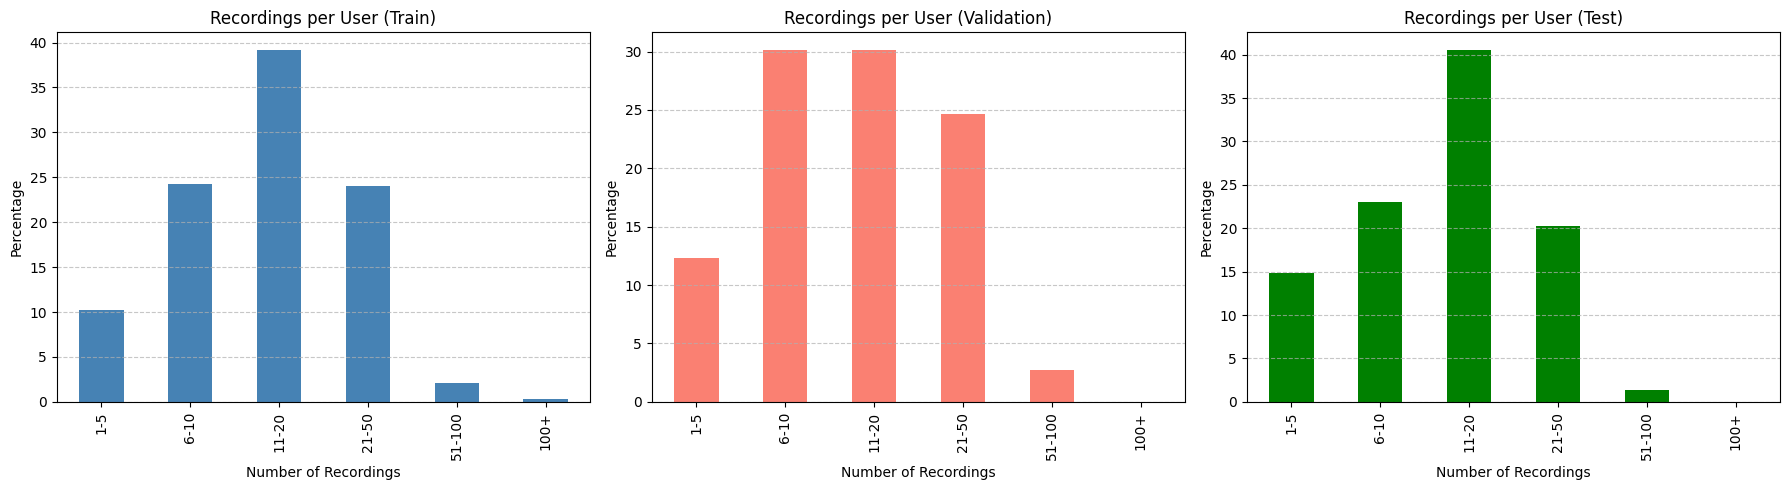

In [ ]:
plot_user_distribution(train_df, val_df, test_df)

In [ ]:
print(f"Train unique users: {train_df['user'].nunique()}")
print(f"Validation unique users: {val_df['user'].nunique()}")
print(f"Test unique users: {test_df['user'].nunique()}")

Train unique users: 342
Validation unique users: 73
Test unique users: 74


In [ ]:
def plot_sentence_distribution(df1, df2, df3):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for df, ax, title, color in zip(
        [df1, df2, df3],
        axes,
        ["Train", "Validation", "Test"],
        ["steelblue", "salmon", "green"]
    ):
        sentence_counts = df['sætning_id'].value_counts()

        bins = [0, 5, 10, 20, 50, 100]
        labels = ['1-5', '6-10', '11-20', '21-50', '50+']

        sentence_bins = pd.cut(sentence_counts, bins=bins, labels=labels)

        dist = sentence_bins.value_counts(normalize=True).sort_index() * 100

        dist.plot(kind='bar', ax=ax, color=color)

        ax.set_title(f"Recordings per Sentence ({title})")
        ax.set_ylabel("Percentage")
        ax.set_xlabel("Number of Recordings")
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

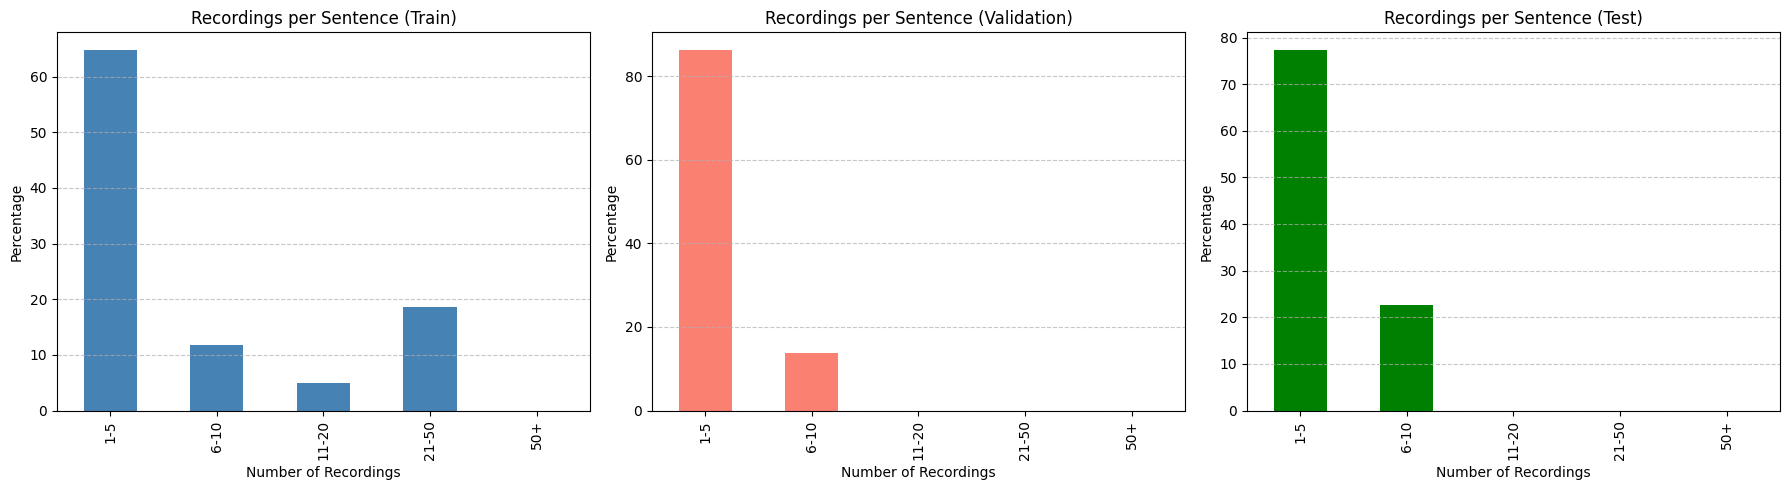

In [ ]:
plot_sentence_distribution(train_df, val_df, test_df)

In [ ]:
print(f"Train unique sentences: {train_df['sætning_id'].nunique()}")
print(f"Validation unique sentences: {val_df['sætning_id'].nunique()}")
print(f"Test unique sentences: {test_df['sætning_id'].nunique()}")

Train unique sentences: 604
Validation unique sentences: 412
Test unique sentences: 343


#Download audio files divided into our train, val and test

Downloading recordings corresponding to the cleaned dataset

In [ ]:
import os
import requests

def download_split(df_subset, base_folder, split_name):

    folder = os.path.join(base_folder, split_name)
    os.makedirs(folder, exist_ok=True)

    total = len(df_subset)

    for i, (_, row) in enumerate(df_subset.iterrows(), start=1):
        donation_id = row['id']

        try:

            url = f"https://donerdinstemme.dk/jsonapi/dds/{donation_id}/file"
            r = requests.get(url, headers=headers)
            fil_url = r.json()["data"]["uri"]["absolute_url"]

            r_lyd = requests.get(fil_url, headers=headers)

            if r_lyd.status_code == 200:
                path = os.path.join(folder, f"{donation_id}.wav")

                with open(path, "wb") as f:
                    f.write(r_lyd.content)

        except Exception as e:
            print(f"Fejl med {donation_id}: {e}")

        if i % 100 == 0 or i == total:
            print(f"{split_name}: {i}/{total} filer hentet")

In [ ]:
base_folder = "audio_data"

download_split(train, base_folder, "train")
download_split(val, base_folder, "val")
download_split(test, base_folder, "test")

train: 100/5405 filer hentet
train: 200/5405 filer hentet
train: 300/5405 filer hentet
train: 400/5405 filer hentet
train: 500/5405 filer hentet
train: 600/5405 filer hentet
train: 700/5405 filer hentet
train: 800/5405 filer hentet
train: 900/5405 filer hentet
train: 1000/5405 filer hentet
train: 1100/5405 filer hentet
train: 1200/5405 filer hentet
train: 1300/5405 filer hentet
train: 1400/5405 filer hentet
train: 1500/5405 filer hentet
train: 1600/5405 filer hentet
train: 1700/5405 filer hentet
train: 1800/5405 filer hentet
train: 1900/5405 filer hentet
train: 2000/5405 filer hentet
train: 2100/5405 filer hentet
train: 2200/5405 filer hentet
train: 2300/5405 filer hentet
train: 2400/5405 filer hentet
train: 2500/5405 filer hentet
train: 2600/5405 filer hentet
train: 2700/5405 filer hentet
train: 2800/5405 filer hentet
train: 2900/5405 filer hentet
train: 3000/5405 filer hentet
train: 3100/5405 filer hentet
train: 3200/5405 filer hentet
train: 3300/5405 filer hentet
train: 3400/5405 fi

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("audio_data", 'zip', "audio_data")
files.download("audio_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checks how many audio files are in each of the three folders

In [ ]:
import os

print(len(os.listdir("audio_data/train")))
print(len(os.listdir("audio_data/val")))
print(len(os.listdir("audio_data/test")))

5405
1088
1100
